# 06. Extensions: Lancaster protocol, neuron and glia fractions

A-line "afternoon 3" from TASKS_day2.md, run with the final model in `src/growth_chart.py`
(logit + heteroskedastic + publication batch effect BLR; chosen in notebook 03, step 9).

1. Lancaster split, `data/split_lancaster.csv`
2. Lancaster, `frac_NPC_IP` -> `results/final_lancaster_npc/`
3. Velasco, `frac_neuron` and `frac_glia` -> `results/final_velasco_neuron/`, `results/final_velasco_glia/`
4. Test metrics for all four charts and a 2 x 2 overview figure

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("..")
sys.path.insert(0, str(ROOT))
from src.growth_chart import fit_growth_chart, plot_growth_chart, test_metrics

FIG = ROOT / "figures"
df_all = pd.read_csv(ROOT / "data" / "hnoca_sample_composition.csv")
velasco = df_all[df_all["protocol"].str.contains("Velasco")].merge(pd.read_csv(ROOT / "data" / "split_velasco.csv"), on="sample")
lancaster = df_all[df_all["protocol"].str.contains("Lancaster")].copy()
print("Velasco", velasco.shape, "  Lancaster", lancaster.shape)

Velasco (131, 29)   Lancaster (81, 28)


## 1. Lancaster train/test split

Same recipe as `data/split_velasco.csv` (TASKS_day1.md): stratified by age bin, 20% test per bin, seed 2026.
Bins are 0-30 / 30-60 / 60-90 / 90-120 because Lancaster stops at day 120. Written once; never refit.

In [2]:
lancaster["age_bin"] = pd.cut(lancaster["age"], [0, 30, 60, 90, 120], labels=False)
rng = np.random.default_rng(2026)
lancaster["split"] = "train"
for b, g in lancaster.groupby("age_bin"):
    test_idx = rng.choice(g.index, size=max(1, round(0.2 * len(g))), replace=False)
    lancaster.loc[test_idx, "split"] = "test"

split_path = ROOT / "data" / "split_lancaster.csv"
if split_path.exists():
    # The split is fixed: reuse the file and check it matches.
    saved = pd.read_csv(split_path)
    assert saved.set_index("sample")["split"].reindex(lancaster["sample"]).tolist() == lancaster["split"].tolist()
else:
    lancaster[["sample", "split"]].to_csv(split_path, index=False)

pd.crosstab([lancaster["age_bin"]], lancaster["split"], margins=True)

split,test,train,All
age_bin,,,
0,7,27,34
1,7,29,36
2,2,6,8
3,1,2,3
All,17,64,81


In [3]:
# Where the Lancaster data are: three publications, and nothing between day 63 and day 120.
lancaster.groupby("publication")["age"].agg(["count", "min", "max", lambda a: sorted(a.unique())]).rename(columns={"<lambda_0>": "ages"})

,count,min,max,ages
publication,,,,
"Fleck, 2022",34,9,61,"[9, 11, 12, 16, 18, 21, 26, 31, 61]"
"He, 2022",18,15,63,"[15, 32, 46, 60, 63]"
"Kanton, 2019",29,10,120,"[10, 15, 30, 60, 120]"


## 2. Lancaster, neural progenitors

The curve is drawn for **Kanton 2019**, the only publication covering day 10 to day 120 (the function's default would be
Fleck 2022, which stops at day 61).

Caveats, to state on any slide that shows this chart:
- 21 of 81 samples have progenitor fraction < 0.5% (all before day 19). The logit model clips them to 0.005, so centiles and z there are unreliable.
- No samples between day 63 and day 120. The curve in that gap is interpolation, not data.
- Only 17 test samples; test z sd is about 1.6, so the chart is under-dispersed (too confident).

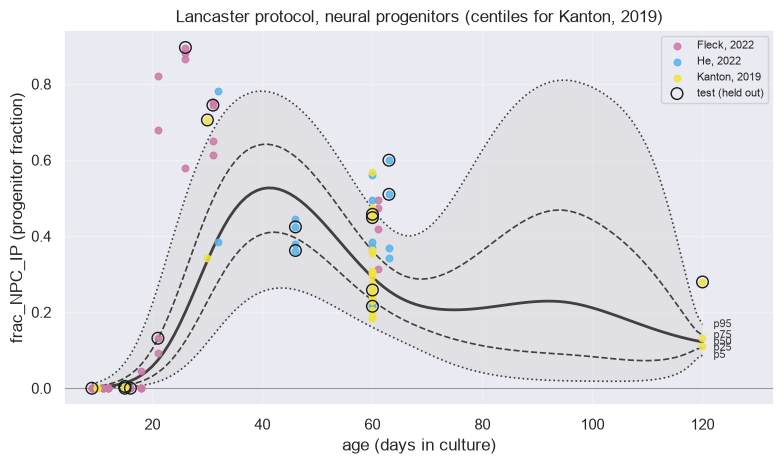

In [4]:
c_lan, z_lan = fit_growth_chart(lancaster, "frac_NPC_IP", model_name="final_lancaster_npc", grid_batch="Kanton, 2019")
plot_growth_chart(c_lan, z_lan, title="Lancaster protocol, neural progenitors", y_label="frac_NPC_IP (progenitor fraction)",
                  path=FIG / "final_lancaster_npc.png")
plt.show()

## 3. Velasco, neurons and glia

Same split, same model, different y. Glia caveat: 51 of 131 samples have glia fraction < 0.5% (gliogenesis has not started
before about day 90), so the glia chart is only meaningful after about day 90. Samples flagged before that are artefacts of the clipping.

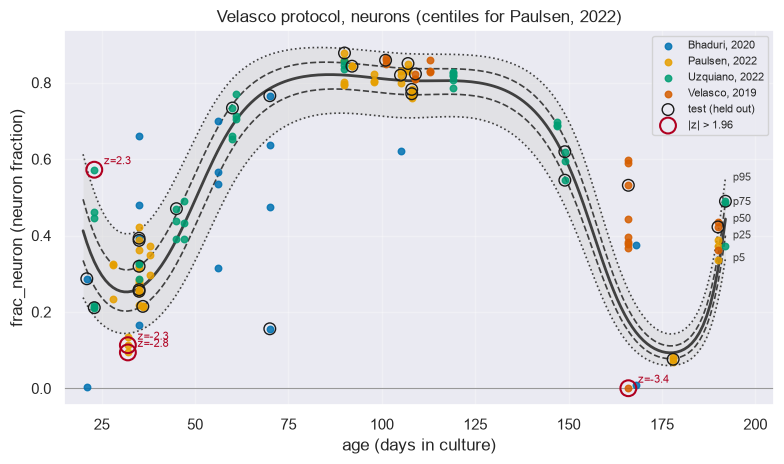

In [5]:
c_neu, z_neu = fit_growth_chart(velasco, "frac_neuron", model_name="final_velasco_neuron")
plot_growth_chart(c_neu, z_neu, title="Velasco protocol, neurons", y_label="frac_neuron (neuron fraction)",
                  annotate_z=1.96, path=FIG / "final_velasco_neuron.png")
plt.show()

**Neuron chart, the dip near day 178 is real data, not a fitting bug.** Paulsen 2022 has three samples at day 178
(two train, one test) that are 86 to 88% glia and only 7 to 8% neurons. The curve is drawn for Paulsen, so it follows them.
It rests on one time point from one lab, so do not read it as a general trajectory.
The day-166 Velasco 2019 sample with 0% neurons, 0% glia and 77% progenitors is flagged in both the NPC chart (z = +3.4)
and the neuron chart (z = -3.4): one atypical (or technically odd) sample, caught consistently by two charts.

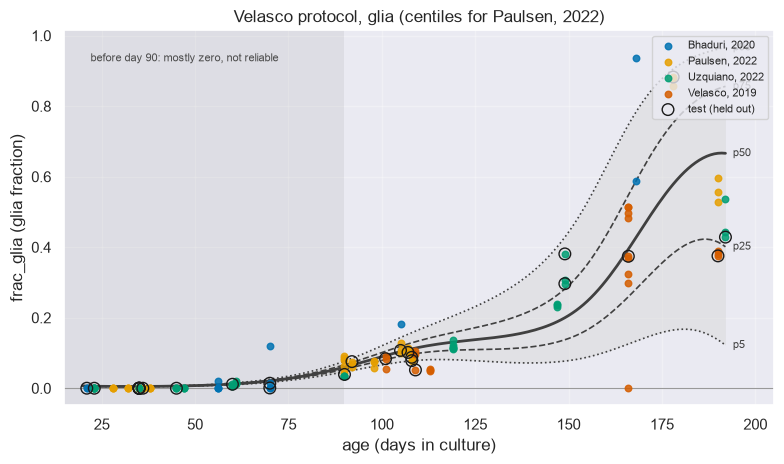

In [6]:
c_gli, z_gli = fit_growth_chart(velasco, "frac_glia", model_name="final_velasco_glia")
ax = plot_growth_chart(c_gli, z_gli, title="Velasco protocol, glia", y_label="frac_glia (glia fraction)")
ax.axvspan(c_gli["age"].min() - 5, 90, color="0.5", alpha=0.12, lw=0)
ax.text(22, 0.95, "before day 90: mostly zero, not reliable", fontsize=8, color="0.3", va="top")
plt.tight_layout()
plt.savefig(FIG / "final_velasco_glia.png", dpi=150)
plt.show()

## 4. Test metrics and overview

Same formulas as notebook 03, step 8. MSLL is comparable only within the same y (different y have different spreads).

In [7]:
z_npc = pd.read_csv(ROOT / "results" / "final_velasco_npc" / "zscores.csv")
c_npc = pd.read_csv(ROOT / "results" / "final_velasco_npc" / "centiles.csv")
c_npc.attrs["grid_batch"] = "Paulsen, 2022"

charts = {"Velasco NPC": (c_npc, z_npc), "Velasco neuron": (c_neu, z_neu),
          "Velasco glia": (c_gli, z_gli), "Lancaster NPC": (c_lan, z_lan)}
final_metrics = pd.DataFrame({k: test_metrics(z) for k, (c, z) in charts.items()}).T
final_metrics.index.name = "chart"
final_metrics.round(4).to_csv(ROOT / "results" / "final_extensions_metrics.csv")
final_metrics.round(3)

,n_test,EV,SMSE,MSLL,z_mean,z_sd,z_skew,z_kurtosis,pct_abs_z_gt_1.96
chart,,,,,,,,,
Velasco NPC,26.0,0.769,0.267,-1.399,0.151,0.868,0.776,1.703,3.846
Velasco neuron,26.0,0.731,0.270,-1.154,0.045,0.790,-0.468,0.028,0.000
Velasco glia,26.0,0.786,0.215,-3.248,-0.144,0.863,-1.135,2.408,3.846
Lancaster NPC,17.0,0.482,0.607,-0.612,0.476,1.629,0.836,0.542,17.647


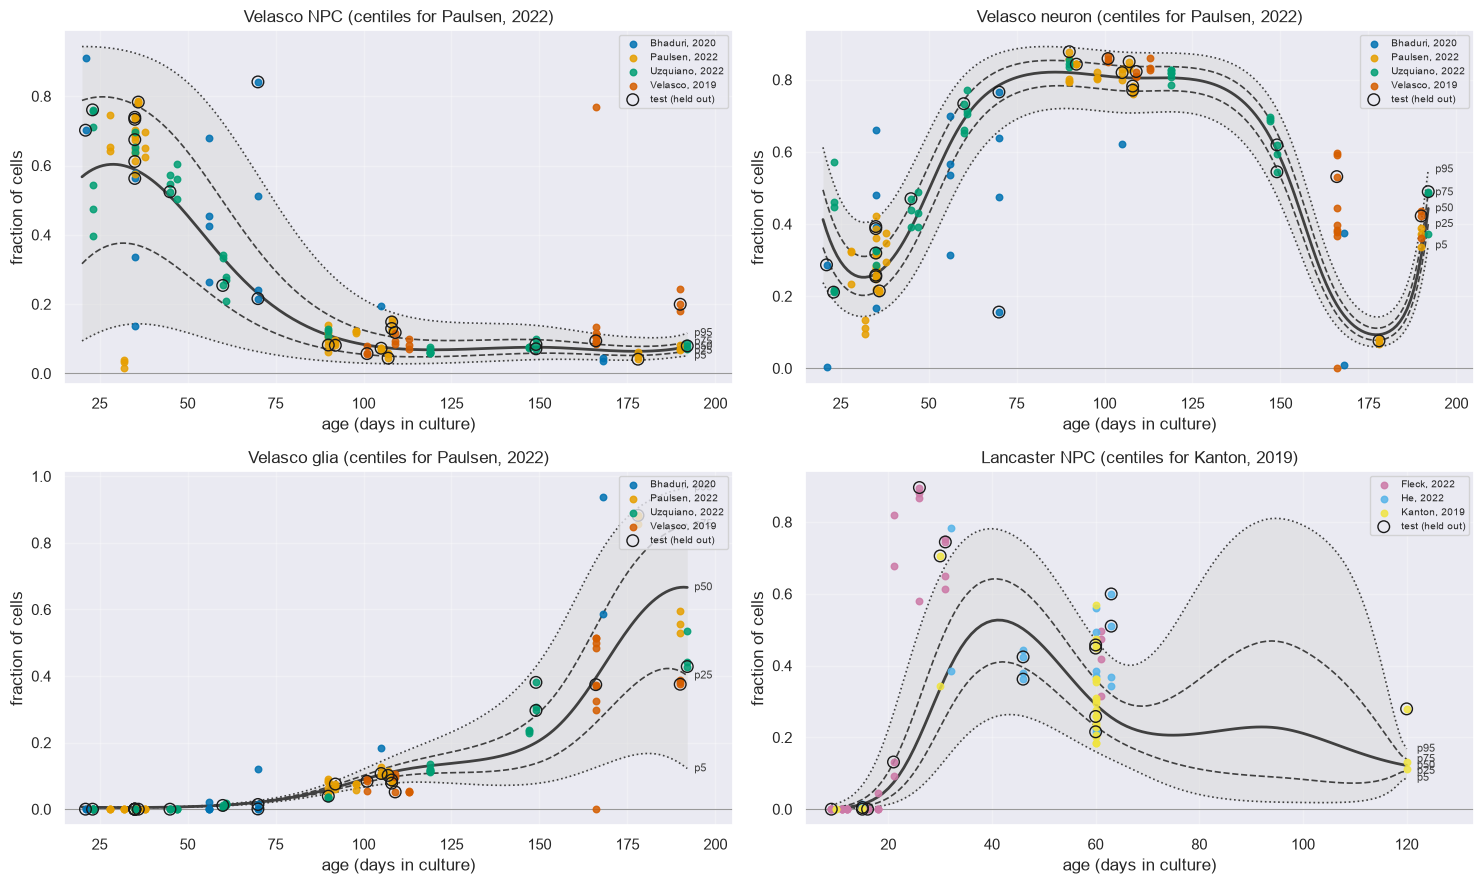

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, (name, (c, z)) in zip(axes.ravel(), charts.items()):
    plot_growth_chart(c, z, title=name, ax=ax, y_label="fraction of cells")
    ax.legend(fontsize=7, loc="upper right")
plt.tight_layout()
plt.savefig(FIG / "final_overview_2x2.png", dpi=150)
plt.show()